In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import cortico_cereb_connectivity.run_model as rm

In [2]:
def heatmap_annotate(df_to_plot, ds_order, ax, ds_order_y=None, column=['train_dataset'], row=['eval_dataset'], value=['R_eval'], cmap='inferno', vmin=0, vmax=0.5):
    if ds_order_y is None:
        if 'Fusion' in ds_order:
            ds_order_y = [ds for ds in ds_order if ds!='Fusion']
        else:
            ds_order_y = ds_order
    V = pd.pivot_table(df_to_plot, columns=column, index=row, values=value)
    V = V.reindex(ds_order_y, axis=0)
    V = V.reindex(ds_order, level=1, axis=1)

    sns.heatmap(V.values, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax, 
                xticklabels=V.columns.get_level_values(1).values, 
                yticklabels=V.index.values, square=True, ax=ax)
    if 'Fusion' in ds_order:
        ax.axvline(len(ds_order_y), color='k', linewidth=2)

    return ax

In [3]:
method = 'NNLS'
cerebellum = 'MNISymC3'
train_ds_list = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]
eval_ds_list = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]
eval_names = ["MDTB", "Languagelocalizer", "Socialsocial", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]

df_all = pd.DataFrame()
for i, ds in enumerate(train_ds_list):
    ev_names = [ev_ds for ev_ds in eval_names if eval_ds_list[eval_names.index(ev_ds)] != ds]

    # load avg models
    df_1 = rm.comb_eval(models=[f'{ds}-avg-Cavg'], eval_data=ev_names, methods=[method], cerebellum=cerebellum)
    df_1["dataset_type"] = 'avg'

    # load loo models
    df_2 = rm.comb_eval(models=[f'{ds}-loo-Cavg'], eval_data=[eval_names[i]], methods=[method], cerebellum=cerebellum)
    df_2["dataset_type"] = 'avg'

    # load group models
    df_3 = rm.comb_eval(models=[f'{ds}-group-Cavg'], eval_data=ev_names, methods=[method], cerebellum=cerebellum)
    df_3["dataset_type"] = 'group'

    # load group loo models
    df_4 = rm.comb_eval(models=[f'{ds}-group_loo-Cavg'], eval_data=[eval_names[i]], methods=[method], cerebellum=cerebellum)
    df_4["dataset_type"] = 'group'

    df_all = pd.concat([df_all, df_1, df_2, df_3, df_4], ignore_index=True)

df_all.loc[df_all['logalpha'].isnull(), 'logalpha'] = -2.0
df_avg = df_all[df_all['dataset_type'] == 'avg'].reset_index(drop=True)
df_group = df_all[df_all['dataset_type'] == 'group'].reset_index(drop=True)

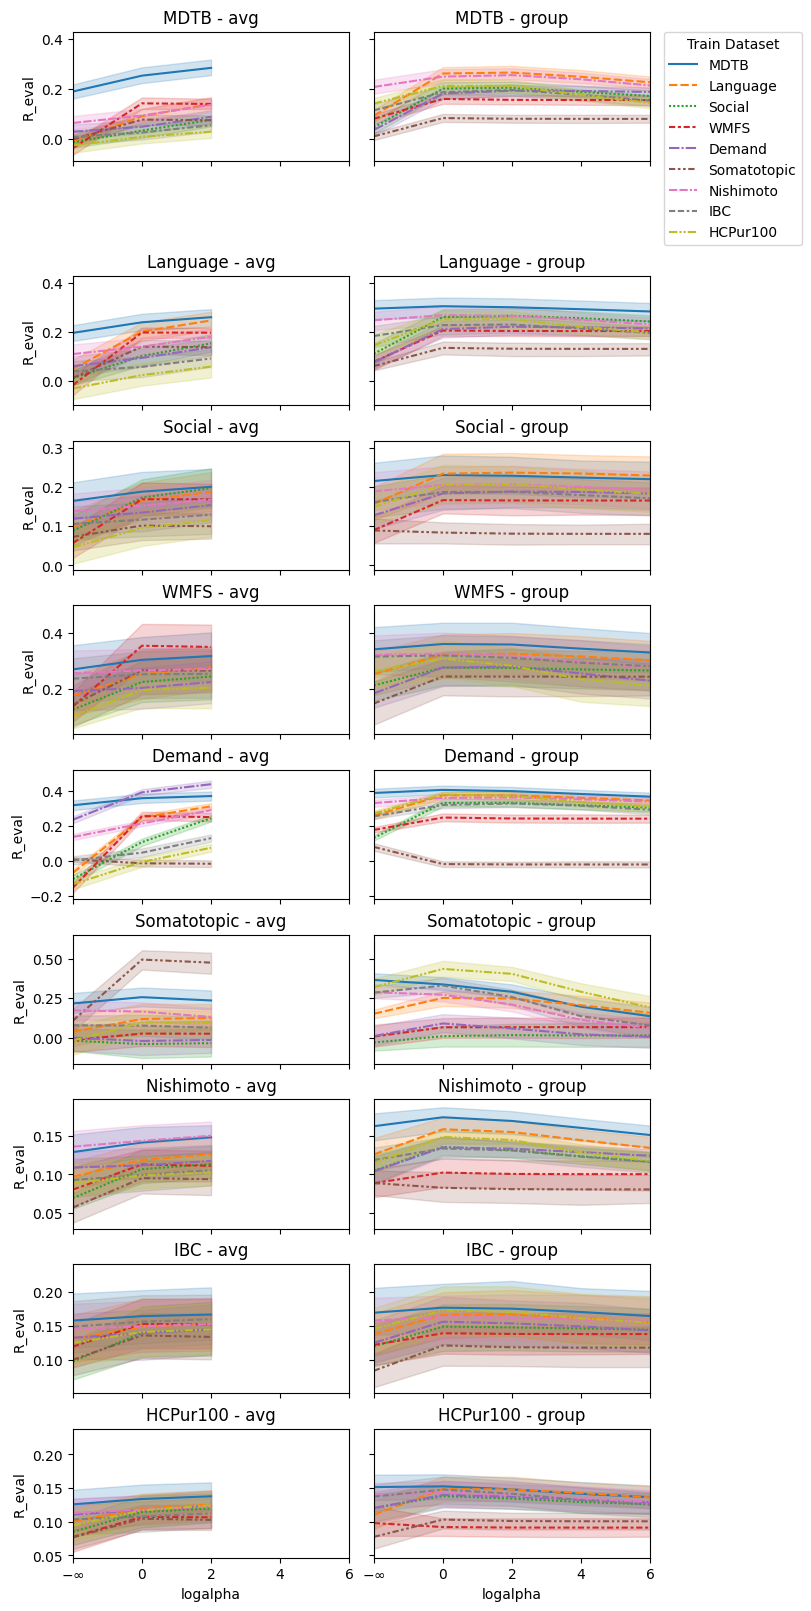

In [4]:
fig, axes = plt.subplots(len(eval_ds_list), 2, figsize=(8, 16), sharey='row', sharex=True, constrained_layout=True)
for i,ed in enumerate(eval_ds_list):
    # Left subplot
    ax_avg = axes[i, 0]
    df_to_plot = df_avg[df_avg.eval_dataset==ed]
    sns.lineplot(data=df_to_plot, y='R_eval', x='logalpha', hue='train_dataset', style='train_dataset',
                     hue_order=train_ds_list, style_order=train_ds_list, legend=False, ax=ax_avg)
    ax_avg.set_title(f'{ed} - avg')

    # Right subplot
    ax_group = axes[i, 1]
    df_to_plot = df_group[df_group.eval_dataset==ed]
    sns.lineplot(data=df_to_plot, y='R_eval', x='logalpha', hue='train_dataset', style='train_dataset',
                     hue_order=train_ds_list, style_order=train_ds_list, ax=ax_group)
    ax_group.set_title(f'{ed} - group')

    for ax in [ax_avg, ax_group]:
        xticks = ax.get_xticks()
        ax.set_xticks(xticks)
        xticklabels = [r"$-\infty$" if np.isclose(t, -2) else str(int(t)) for t in xticks]
        ax.set_xticklabels(xticklabels)
        ax.set_xlim(-2, 6)

    if i == 0:
        ax_group.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Train Dataset')
    else:
        ax_group.get_legend().remove()

### Find best Hyperparameter

In [8]:
# avg
A = pd.pivot_table(df_avg[df_avg.model!='loo'], index=['train_dataset'],columns=['logalpha'],values=['R_eval'],aggfunc='mean').reindex(train_ds_list)
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_avg['isbest'] = df_avg.logalpha.values == bestla.loc[df_avg.train_dataset].values.flatten()

R_eval                    
logalpha           -2.0       0.0       2.0
train_dataset                              
MDTB           0.200533  0.225269  0.233523
Language       0.055207  0.162607  0.190266
Social         0.022025  0.104727  0.149814
WMFS           0.000433  0.159108  0.157116
Demand         0.098146  0.110109  0.128837
Somatotopic    0.052992  0.095846  0.093798
Nishimoto      0.130874  0.156665  0.183394
IBC            0.074489  0.091689  0.118548
HCPur100      -0.010816  0.061098  0.094106

,best_logalpha
train_dataset,
MDTB,2.0
Language,2.0
Social,2.0
WMFS,0.0
Demand,2.0
Somatotopic,0.0
Nishimoto,2.0
IBC,2.0
HCPur100,2.0


In [9]:
# group
A = pd.pivot_table(df_group[df_group.model!='group_loo'], index=['train_dataset'],columns=['logalpha'],values=['R_eval'],aggfunc='mean').reindex(train_ds_list)
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_group['isbest'] = df_group.logalpha.values == bestla.loc[df_group.train_dataset].values.flatten()

R_eval                                        
logalpha           -2.0       0.0       2.0       4.0       6.0
train_dataset                                                  
MDTB           0.256151  0.264730  0.258491  0.244937  0.233710
Language       0.162270  0.244721  0.245183  0.234715  0.221660
Social         0.112107  0.208649  0.208690  0.199861  0.191330
WMFS           0.106343  0.156481  0.154227  0.153893  0.153847
Demand         0.104244  0.173041  0.174059  0.167073  0.160081
Somatotopic    0.075963  0.089453  0.087200  0.086831  0.086780
Nishimoto      0.225191  0.241046  0.238088  0.223897  0.209830
IBC            0.187168  0.223403  0.220762  0.203210  0.186741
HCPur100       0.199653  0.276349  0.269995  0.235287  0.209582

,best_logalpha
train_dataset,
MDTB,0.0
Language,2.0
Social,2.0
WMFS,0.0
Demand,2.0
Somatotopic,0.0
Nishimoto,0.0
IBC,0.0
HCPur100,0.0


In [10]:
# Create a subset for best logalpha values
df_avg_best = df_avg[df_avg.isbest]
df_group_best = df_group[df_group.isbest]
df_avg_noReg = df_avg[df_avg.logalpha == -2.0]
df_group_noReg = df_group[df_group.logalpha == -2.0]

### Evaluation Heatmap at best Hyperparameter

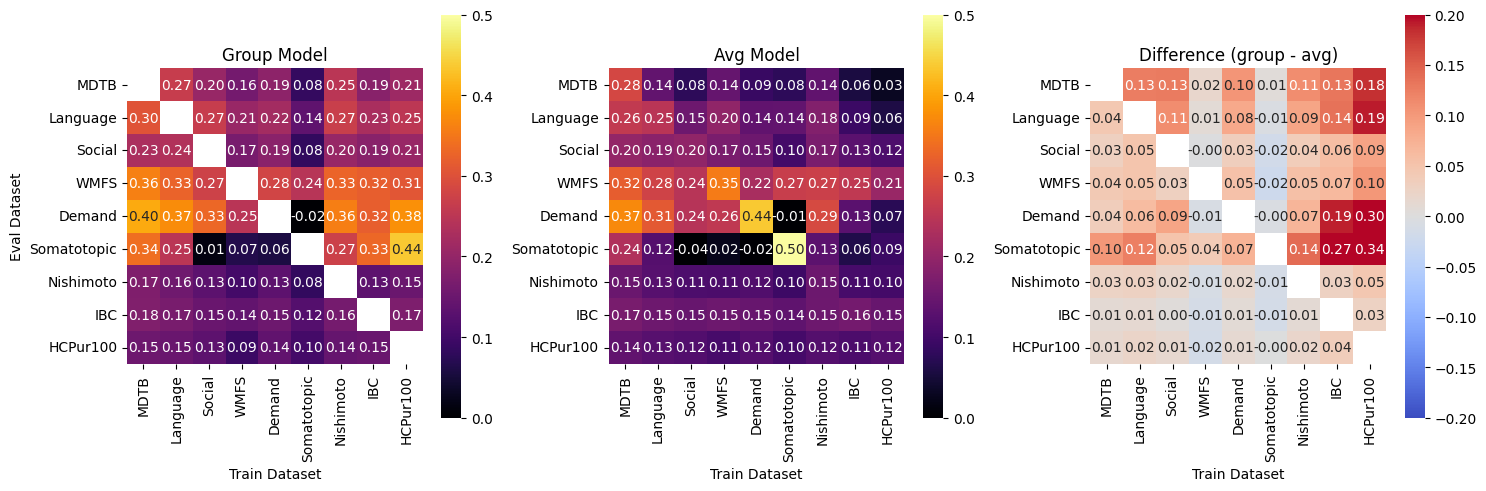

In [11]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

ax = heatmap_annotate(df_group_best, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[0], value=['R_eval'],
                      cmap='inferno', vmin=0, vmax=0.5)
ax.set_title('Group Model')
ax.set_xlabel('Train Dataset')
ax.set_ylabel('Eval Dataset')

ax = heatmap_annotate(df_avg_best, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[1], value=['R_eval'],
                      cmap='inferno', vmin=0, vmax=0.5)
ax.set_title('Avg Model')
ax.set_xlabel('Train Dataset')

# Calculate the difference in 'R_eval' for the same group of (train_dataset, eval_dataset, eval_subj)
df_diff = pd.merge(df_avg_best[['train_dataset', 'eval_dataset', 'eval_subj', 'R_eval']],
                   df_group_best[['train_dataset', 'eval_dataset', 'eval_subj', 'R_eval']],
                   on=['train_dataset', 'eval_dataset', 'eval_subj'],
                   suffixes=('_avg', '_group'))

df_diff['R_eval_diff'] = df_diff['R_eval_group'] - df_diff['R_eval_avg']
ax = heatmap_annotate(df_diff, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[2], value=['R_eval_diff'],
                      cmap='coolwarm', vmin=-0.2, vmax=0.2)
ax.set_title('Difference (group - avg)')
ax.set_xlabel('Train Dataset')

plt.tight_layout()

### Evaluation Heatmap at no Regularization

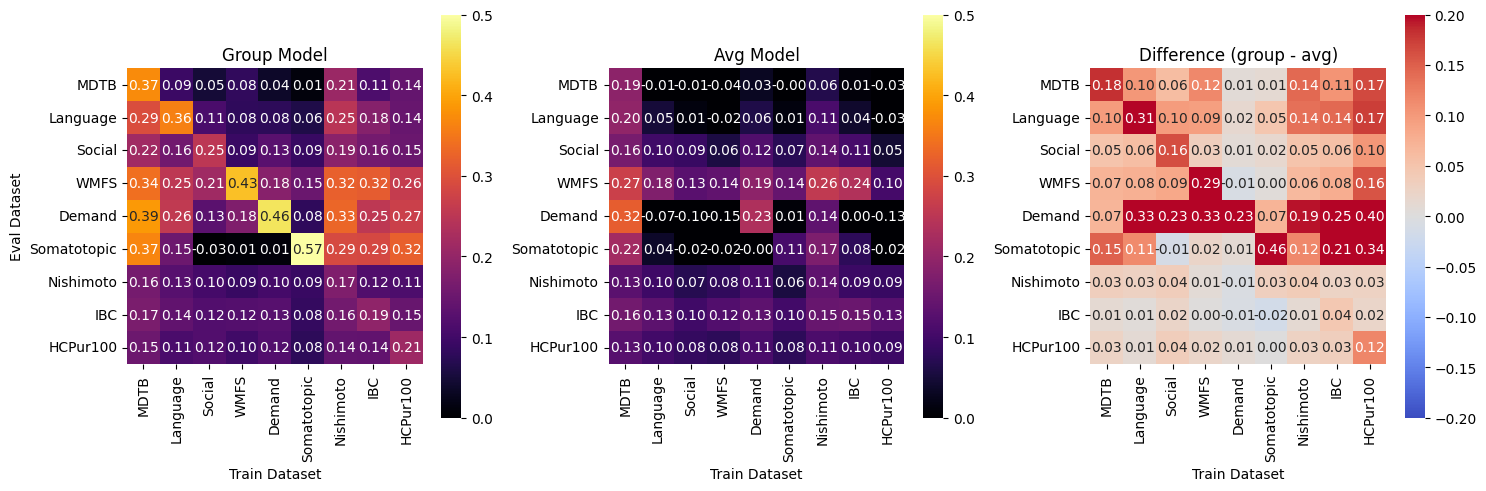

In [12]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

ax = heatmap_annotate(df_group_noReg, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[0], value=['R_eval'],
                      cmap='inferno', vmin=0, vmax=0.5)
ax.set_title('Group Model')
ax.set_xlabel('Train Dataset')
ax.set_ylabel('Eval Dataset')

ax = heatmap_annotate(df_avg_noReg, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[1], value=['R_eval'],
                      cmap='inferno', vmin=0, vmax=0.5)
ax.set_title('Avg Model')
ax.set_xlabel('Train Dataset')

# Calculate the difference in 'R_eval' for the same group of (train_dataset, eval_dataset, eval_subj)
df_diff_noReg = pd.merge(df_avg_noReg[['train_dataset', 'eval_dataset', 'eval_subj', 'R_eval']],
                   df_group_noReg[['train_dataset', 'eval_dataset', 'eval_subj', 'R_eval']],
                   on=['train_dataset', 'eval_dataset', 'eval_subj'],
                   suffixes=('_avg', '_group'))

df_diff_noReg['R_eval_diff'] = df_diff_noReg['R_eval_group'] - df_diff_noReg['R_eval_avg']
ax = heatmap_annotate(df_diff_noReg, ds_order=train_ds_list, ds_order_y=eval_ds_list, ax=axes[2], value=['R_eval_diff'],
                      cmap='coolwarm', vmin=-0.2, vmax=0.2)
ax.set_title('Difference (group - avg)')
ax.set_xlabel('Train Dataset')

plt.tight_layout()